importamos librerias

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



capturamos origen de data:

In [5]:
url="https://raw.githubusercontent.com/ccastaneda-boot/Parcial4-CarlosCasta-eda-1743602001/refs/heads/main/data/clave_D_agrupacion.csv"

cargamos dataset

In [6]:
df=pd.read_csv(url)
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,D-R0063,35,444,1.58,5.00,8.00,1,17
1,D-R0103,49,712,8.23,74.67,8.89,2,22
2,D-R0141,49,1632,9.47,150.66,7.90,0,36
3,D-R0077,39,968,8.16,91.96,9.59,12,12
4,D-R0119,34,675,5.66,59.92,9.03,0,16


**Verificamos su estructura y vemos primeras filas del dataset:**

In [7]:
print(df.shape)
print(df.head())
print(df.info())


(242, 8)
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     D-R0063    35       444            1.58            5.00          8.00   
1     D-R0103    49       712            8.23           74.67          8.89   
2     D-R0141    49      1632            9.47          150.66          7.90   
3     D-R0077    39       968            8.16           91.96          9.59   
4     D-R0119    34       675            5.66           59.92          9.03   

   reclamos  antiguedad_meses  
0         1                17  
1         2                22  
2         0                36  
3        12                12  
4         0                16  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       242 non-null    object 
 1   edad              242 non-null    int64  
 2   ingresos          242 non-n

In [12]:
print("\nDatos Nulos")
print(df.isnull().sum())

print("\nValores Duplicados")
print(df.duplicated().sum())

print("\nVariables atípicas")
variables_numericas = [ "ingresos", "gasto_promedio"]

print("\nRevisión de valores atípicos:")
for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Media:", round(media, 2))
    print("Desviación estándar:", round(desviacion, 2))
    print("Límite inferior:", round(limite_inferior, 2))
    print("Límite superior:", round(limite_superior, 2))
    print("Cantidad de valores atípicos:", len(outliers))
    print("-" * 40)


Datos Nulos
registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64

Valores Duplicados
0

Variables atípicas

Revisión de valores atípicos:
Variable: ingresos
Media: 997.13
Desviación estándar: 426.25
Límite inferior: 144.63
Límite superior: 1849.63
Cantidad de valores atípicos: 4
----------------------------------------
Variable: gasto_promedio
Media: 78.5
Desviación estándar: 47.27
Límite inferior: -16.04
Límite superior: 173.04
Cantidad de valores atípicos: 4
----------------------------------------


Realizamos el analisis de agrupación entre variables (usaremos cluster k4):

/tmp/ipykernel_26238/850246890.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['satisfaccion'].fillna(X['satisfaccion'].mean(), inplace=True)


            edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
Cluster_4                                                                  
0          40.96    816.98            3.84           60.12          4.72   
1          33.91   1012.72            6.64           82.05          7.97   
2          48.24   1571.45            8.79          146.60          8.83   
3          26.58    618.81            2.10           29.71          6.06   

           reclamos  antiguedad_meses  
Cluster_4                              
0              5.26             12.34  
1              1.15             18.97  
2              0.83             36.67  
3              2.82              5.85  


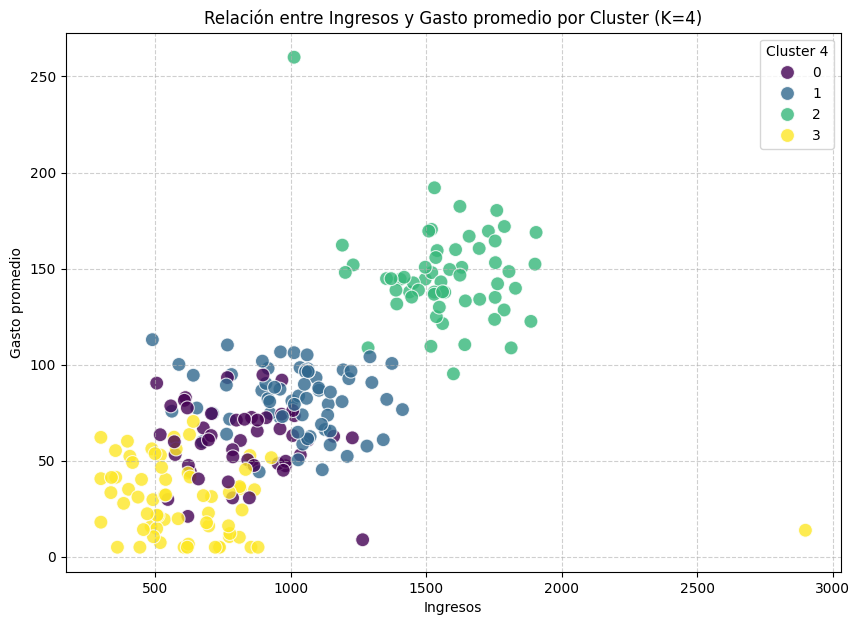

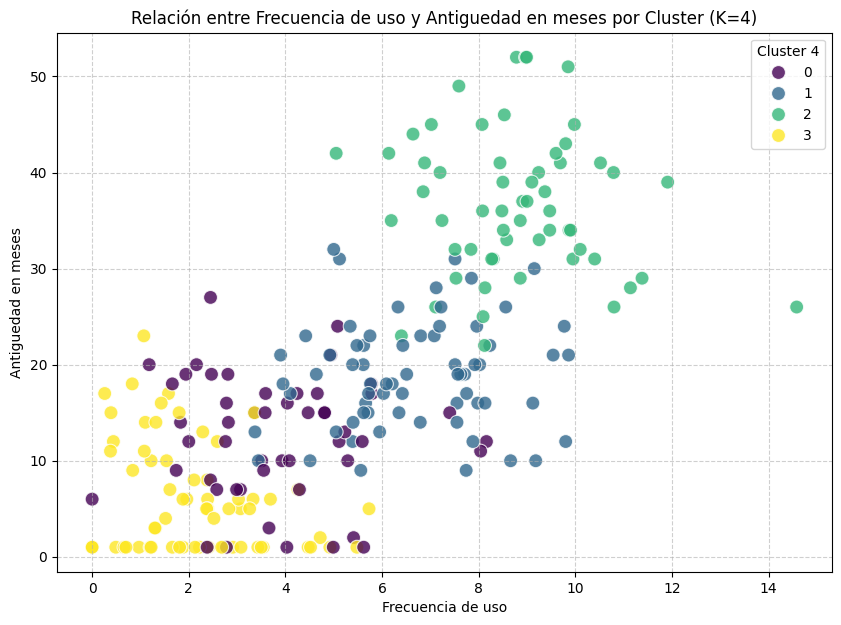

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

columnas_cluster = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos','antiguedad_meses']
X = df[columnas_cluster].copy()

# Imputar valores nulos en la columna 'satisfaccion' con la media
X['satisfaccion'].fillna(X['satisfaccion'].mean(), inplace=True)

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)


print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='ingresos', y='gasto_promedio', hue='Cluster_4', palette='viridis', s=100, alpha=0.8)
plt.title('Relación entre Ingresos y Gasto promedio por Cluster (K=4)')
plt.xlabel('Ingresos')
plt.ylabel('Gasto promedio')
plt.legend(title='Cluster 4')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='frecuencia_uso', y='antiguedad_meses', hue='Cluster_4', palette='viridis', s=100, alpha=0.8)
plt.title('Relación entre Frecuencia de uso y Antiguedad en meses por Cluster (K=4)')
plt.xlabel('Frecuencia de uso')
plt.ylabel('Antiguedad en meses')
plt.legend(title='Cluster 4')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()





### Interpretación de los Grupos (Clusters)

#### Interpretación para K=4 Clusters

*   **Cluster 0:**
    Clientes alrededor de 40 años, con ingresos bajos y baja frecuencia de uso. Tambien tienen un gasto promedio bajo y baja satisfacción (tienen reclamos altos) y su antigüedad es media. Son clientes insatisfechos y poco activos.

*   **Cluster 1:**
    Clientes alrededor de los 34 años, con ingresos medios y frecuencia de uso alta, tiene un gasto promedio medio y demuestran alta satisfacción. Por ende, tienen baja frecuencia de reclamos. tienen una antigüedad media a alta. Se pueden interpretar como clientes leales y satisfechos.

*   **Cluster 2:**
    Clientes alrededor de los 48 años, con ingresos muy altos, frecuencia de usuo, gasto promedio y satisfacción muy alta. Los reclamos son muy bajos y son clientes con una antigüedad alta. Podemos decir que son los clientes de clase A para la empresa.

*   **Cluster 3:**
    Clientes en los 27 años, con ingresos muy bajos, por ende una frecuencia de uso muy baja así como su gasto promedio. Su satisfacción y reclamos es media, con antigüedad baja. Estos son clientes nuevos de bajo valor.

#### Acciones de negocio para cada grupo (Clusters K4):

*   **Cluster 0
    Generar programas de retención o insentivos que les brineden beneficios para reengancharlos. implementar encuestas de satisfacción (como NPS) que permitan actuar sobre los resultados de estas.

*   **Cluster 1
    Crear programas de fidelización, que recompencen su antigüedad y lealtad. Darles trato personalizado y generarles reconocimiento a traves de comunicados o eventos.

*   **Cluster 2
    A estos clientes se les debe brindar servicios exclusivos (como clientes premium), donde puedan participar en preventas, ofertas exclusivas de alto valor, eventos VIP.

*   **Cluster 3
    Se pueden crear insentivos para que se activen y motiven a comprar, como pequeños descuentos o veneficios (por ej. descuentos en tu primer compra). Generar contenido dirigido a ellos para que conoscan los beneficios que puedan obtener y sacarle el maximo provecho a sus compras.